<a href="https://colab.research.google.com/github/isaacadebayo/Predictive-Analytics-Public-Datasets/blob/main/Visual_Transformer_and_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

dataset = '/content/drive/MyDrive/Vegetable_Images/train'


full_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset,
    labels='inferred',
    label_mode='int',
    image_size=(128, 128), # You can adjust the image size
    interpolation='nearest',
    batch_size=None # Load images without batching for splitting
)

Found 15000 files belonging to 15 classes.


In [5]:
max_samples = 600   # adjust as needed (e.g., 500–1000 for faster scikit-learn training)

images = []
labels = []
i = 0  # Initialize the counter

for img, label in full_dataset: # Use the correct dataset variable
    if i >= max_samples:
        break
    images.append(img.numpy())
    labels.append(label.numpy())
    i += 1 # Increment the counter

X = np.array(images)
y = np.array(labels)

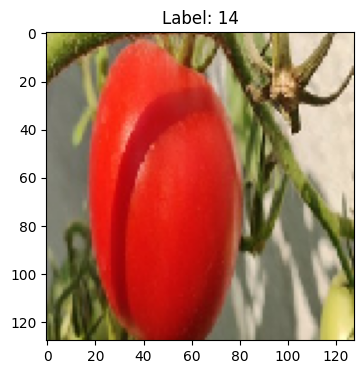

In [6]:
idx = np.random.randint(0, len(X))
plt.figure(figsize=(4, 4))
plt.imshow(X[idx])
plt.title(f"Label: {y[idx]}")
plt.show()

# Resampling and Augmentation

In [7]:
# Split the data into training and testing sets
# Use stratify=y to ensure the class distribution is similar in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, # Adjust the test size as needed
    random_state=42, # Set a random state for reproducibility
    stratify=y
)
print('X.shape', X.shape)
print('y.shape', y.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("y_train count:", np.bincount(y_train))
print("y_test count:", np.bincount(y_test))

X.shape (600, 128, 128, 3)
y.shape (600,)
X_train shape: (480, 128, 128, 3)
X_test shape: (120, 128, 128, 3)
y_train shape: (480,)
y_test shape: (120,)
y_train count: [22 27 34 33 30 32 42 29 31 33 32 46 32 27 30]
y_test count: [ 6  7  9  8  8  8 10  7  8  8  8 11  8  7  7]


In [8]:
# === FIX: ensure labels are 1-D ints and capture class names ===
y = y.reshape(-1).astype('int32')
y_train = y_train.reshape(-1).astype('int32')
y_test  = y_test.reshape(-1).astype('int32')

try:
    class_names = list(getattr(full_dataset, 'class_names', []))
    if class_names and len(class_names) != len(np.unique(y)):
        # fallback if mismatch
        class_names = [str(i) for i in range(len(np.unique(y)))]
except Exception:
    class_names = [str(i) for i in range(len(np.unique(y)))]

n_classes = len(np.unique(y))
print("n_classes:", n_classes, "class_names:", class_names if len(class_names)<=10 else class_names[:10])

n_classes: 15 class_names: ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber']


In [9]:
from imblearn.over_sampling import RandomOverSampler

def oversample_with_imblearn(X, y):
    # Get original shape
    N, H, W, C = X.shape

    # Flatten for imblearn (samples, features)
    X_flat = X.reshape(N, -1)

    # Create oversampler
    ros = RandomOverSampler()

    # Perform oversampling
    X_res, y_res = ros.fit_resample(X_flat, y)

    # Reshape back to image form
    X_res = X_res.reshape(-1, H, W, C)

    return X_res, y_res

In [10]:
np.unique(y_train, return_counts=True)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
       dtype=int32),
 array([22, 27, 34, 33, 30, 32, 42, 29, 31, 33, 32, 46, 32, 27, 30]))

# Create balanced subsample

In [11]:
X_train_bal, y_train_bal = oversample_with_imblearn(X_train, y_train)

print("Before balancing:", np.bincount(y_train))
print("After balancing: ", np.bincount(y_train_bal))

Before balancing: [22 27 34 33 30 32 42 29 31 33 32 46 32 27 30]
After balancing:  [46 46 46 46 46 46 46 46 46 46 46 46 46 46 46]


# Models

# Multimodal Cifar

In [12]:
'''# -----------------------------------------------------------
# Build two-input CNN model
# -----------------------------------------------------------
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *

dropout_rate = 0.2
n_classes  = np.unique(y_train).shape[0]

# Image input and CNN
img_input = Input(shape=X_train.shape[1:], name="image_input")

x = Conv2D(8, (3, 3), activation='relu', padding='same')(img_input)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = BatchNormalization()(x)
x = Dropout(dropout_rate)(x)

x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = BatchNormalization()(x)
x = Dropout(dropout_rate)(x)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = BatchNormalization()(x)
x = Dropout(dropout_rate)(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)

x = GlobalAveragePooling2D()(x)

# Type input (scalar: 0 or 1)
type_input = Input(shape=(1,), name="type_input")

# Concatenate CNN features with type
concat = Concatenate()([x, type_input])

output = Dense(n_classes, activation='softmax')(concat)

# Final model
model = Model(inputs=[img_input, type_input], outputs=output)
model.summary()'''

'# -----------------------------------------------------------\n# Build two-input CNN model\n# -----------------------------------------------------------\nfrom tensorflow.keras.models import Model\nfrom tensorflow.keras.layers import *\n\ndropout_rate = 0.2\nn_classes  = np.unique(y_train).shape[0]\n\n# Image input and CNN\nimg_input = Input(shape=X_train.shape[1:], name="image_input")\n\nx = Conv2D(8, (3, 3), activation=\'relu\', padding=\'same\')(img_input)\nx = MaxPooling2D(pool_size=(2, 2))(x)\nx = BatchNormalization()(x)\nx = Dropout(dropout_rate)(x)\n\nx = Conv2D(16, (3, 3), activation=\'relu\', padding=\'same\')(x)\nx = MaxPooling2D(pool_size=(2, 2))(x)\nx = BatchNormalization()(x)\nx = Dropout(dropout_rate)(x)\n\nx = Conv2D(32, (3, 3), activation=\'relu\', padding=\'same\')(x)\nx = MaxPooling2D(pool_size=(2, 2))(x)\nx = BatchNormalization()(x)\nx = Dropout(dropout_rate)(x)\n\nx = Conv2D(64, (3, 3), activation=\'relu\', padding=\'same\')(x)\nx = MaxPooling2D(pool_size=(2, 2))(x

In [13]:
'''from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

epochs = 15
batch_size = 256
initial_learning_rate = 0.01

optimizer = Adam(learning_rate=initial_learning_rate)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)'''

"from tensorflow.keras.optimizers import Adam\nfrom tensorflow.keras.callbacks import EarlyStopping\n\nepochs = 15\nbatch_size = 256\ninitial_learning_rate = 0.01\n\noptimizer = Adam(learning_rate=initial_learning_rate)\n\nmodel.compile(\n    optimizer=optimizer,\n    loss='sparse_categorical_crossentropy',\n    metrics=['accuracy']\n)\n\nearly_stopping = EarlyStopping(\n    monitor='val_loss',\n    patience=10,\n    restore_best_weights=True\n)"

In [14]:
'''from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the image generator with augmentation options
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,      # Rotate images randomly
    width_shift_range=0.2,  # Randomly shift the width of images
    height_shift_range=0.2, # Randomly shift the height of images
    zoom_range=0.1,         # Randomly zoom
)'''

'from tensorflow.keras.preprocessing.image import ImageDataGenerator\n\n# Define the image generator with augmentation options\ndatagen = ImageDataGenerator(\n    rescale=1./255,\n    rotation_range=30,      # Rotate images randomly\n    width_shift_range=0.2,  # Randomly shift the width of images\n    height_shift_range=0.2, # Randomly shift the height of images\n    zoom_range=0.1,         # Randomly zoom\n)'

In [15]:
'''# Generate dummy type_input for train and test sets
# Assuming type_input is a scalar (e.g., 0 or 1), let's use 0 for all for now.
type_train = np.zeros((X_train_bal.shape[0], 1))
type_test = np.zeros((X_test.shape[0], 1))

# Custom generator to combine image batches from ImageDataGenerator with the type input
def custom_multimodal_generator(image_data_generator, type_data_array):
    # Determine the constant type value for this generator based on the first element of type_data_array.
    # This assumes type_data_array contains a constant value for all samples in this dataset (train or test).
    constant_type_value = type_data_array[0][0]

    for X_batch, y_batch in image_data_generator:
        # Create a type_batch of the correct size with the constant value
        type_batch = np.full((X_batch.shape[0], 1), constant_type_value, dtype='float32')
        # Yield a tuple of inputs (image, type) and the corresponding labels
        yield (X_batch, type_batch), y_batch

# Instantiate image data generators
train_image_generator = datagen.flow(
    X_train_bal, y_train_bal,
    batch_size=batch_size,
    shuffle=True,
)

validation_image_generator = datagen.flow(
    X_test, y_test,
    batch_size=batch_size,
    shuffle=False,
)

# Instantiate custom multimodal generators
train_generator_multimodal = custom_multimodal_generator(train_image_generator, type_train)
validation_generator_multimodal = custom_multimodal_generator(validation_image_generator, type_test)
'''

"# Generate dummy type_input for train and test sets\n# Assuming type_input is a scalar (e.g., 0 or 1), let's use 0 for all for now.\ntype_train = np.zeros((X_train_bal.shape[0], 1))\ntype_test = np.zeros((X_test.shape[0], 1))\n\n# Custom generator to combine image batches from ImageDataGenerator with the type input\ndef custom_multimodal_generator(image_data_generator, type_data_array):\n    # Determine the constant type value for this generator based on the first element of type_data_array.\n    # This assumes type_data_array contains a constant value for all samples in this dataset (train or test).\n    constant_type_value = type_data_array[0][0]\n\n    for X_batch, y_batch in image_data_generator:\n        # Create a type_batch of the correct size with the constant value\n        type_batch = np.full((X_batch.shape[0], 1), constant_type_value, dtype='float32')\n        # Yield a tuple of inputs (image, type) and the corresponding labels\n        yield (X_batch, type_batch), y_batch

In [16]:
'''history = model.fit(
    train_generator_multimodal,
    epochs=15,
    validation_data=validation_generator_multimodal,
    verbose=1,
    callbacks=[early_stopping]
)'''

'history = model.fit(\n    train_generator_multimodal,\n    epochs=15,\n    validation_data=validation_generator_multimodal,\n    verbose=1,\n    callbacks=[early_stopping]\n)'

In [17]:
'''from sklearn.metrics import classification_report, confusion_matrix

# Predictions
y_test_pred = model.predict([X_test, type_test]).argmax(axis=1)

# Training plots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('CNN with Type Input', fontsize=16)

# Left: loss curves
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Right: confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[1], vmin=0,
            annot_kws={"size": 12}, cmap='nipy_spectral')
axes[1].set_title('Confusion Matrix (Test Data)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Classification report
from sklearn.metrics import classification_report
report = classification_report(y_test, y_test_pred)
print(report)'''

'from sklearn.metrics import classification_report, confusion_matrix\n\n# Predictions\ny_test_pred = model.predict([X_test, type_test]).argmax(axis=1)\n\n# Training plots\nfig, axes = plt.subplots(1, 2, figsize=(10, 4))\nfig.suptitle(\'CNN with Type Input\', fontsize=16)\n\n# Left: loss curves\naxes[0].plot(history.history[\'loss\'], label=\'Training Loss\')\naxes[0].plot(history.history[\'val_loss\'], label=\'Validation Loss\')\naxes[0].set_title(\'Training and Validation Loss\')\naxes[0].set_xlabel(\'Epochs\')\naxes[0].set_ylabel(\'Loss\')\naxes[0].legend()\n\n# Right: confusion matrix\ncm = confusion_matrix(y_test, y_test_pred)\nsns.heatmap(cm, annot=True, fmt=\'d\', ax=axes[1], vmin=0,\n            annot_kws={"size": 12}, cmap=\'nipy_spectral\')\naxes[1].set_title(\'Confusion Matrix (Test Data)\')\naxes[1].set_xlabel(\'Predicted Label\')\naxes[1].set_ylabel(\'True Label\')\n\nplt.tight_layout(rect=[0, 0, 1, 0.95])\nplt.show()\n\n# Classification report\nfrom sklearn.metrics import 

# Cifar

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

dropout_rate = 0.1

n_classes  = np.unique(y_train_bal).shape[0]

# Create model
model = Sequential([
    Input(shape=X_train_bal.shape[1:]),

    Conv2D(8, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(),
    BatchNormalization(),
    Dropout(dropout_rate),

    Conv2D(16, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(),
    BatchNormalization(),
    Dropout(dropout_rate),

    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(),

    GlobalAveragePooling2D(),

    Dense(n_classes, activation='softmax'),
])

# Define the optimizer with a custom learning rate
optimizer = Adam(learning_rate=0.01)

# Compile model
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=10,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

# Display model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │           495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,623 (25.87 KB)

 Trainable params: 6,575 (25.68 KB)

 Non-trainable params: 48 (192.00 B)

In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the image generator with augmentation options
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,      # Rotate images randomly
    width_shift_range=0.2,  # Randomly shift the width of images
    height_shift_range=0.2, # Randomly shift the height of images
    zoom_range=0.1,         # Randomly zoom
)

In [20]:
# === FIX: clean evaluation helpers ===
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def evaluate_with_rescale(model, X_test, y_test, class_names=None, rescale=1./255, batch_size=128, verbose=0, title="Fixed Evaluation"):
    """Evaluate a CNN trained with ImageDataGenerator(rescale=...) on raw arrays.
    Uses NO augmentation and preserves order (shuffle=False).
    """
    test_gen = ImageDataGenerator(rescale=rescale)
    flow = test_gen.flow(X_test, y_test, batch_size=batch_size, shuffle=False)
    y_pred = model.predict(flow, verbose=verbose).argmax(axis=1)
    print(title)
    print(classification_report(y_test, y_pred, target_names=class_names if class_names and len(class_names)==len(np.unique(y_test)) else None, digits=4))
    return y_pred

def evaluate_direct(model, X_test_encoded, y_test, class_names=None, verbose=0, title="Fixed Evaluation (encoded)"):
    y_pred = model.predict(X_test_encoded, verbose=verbose).argmax(axis=1)
    print(title)
    print(classification_report(y_test, y_pred, target_names=class_names if class_names and len(class_names)==len(np.unique(y_test)) else None, digits=4))
    return y_pred

In [21]:
history = model.fit(
    datagen.flow(
        X_train_bal, y_train_bal,
        batch_size=256,
        shuffle=True,
        ),
    epochs=15,
    validation_data=datagen.flow(
        X_test, y_test
        ),
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 5s/step - accuracy: 0.1319 - loss: 2.5856 - val_accuracy: 0.0833 - val_loss: 2.6892
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.2768 - loss: 2.2271 - val_accuracy: 0.0583 - val_loss: 2.7019
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.3841 - loss: 1.9858 - val_accuracy: 0.0583 - val_loss: 2.7907
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.3826 - loss: 1.8675 - val_accuracy: 0.0833 - val_loss: 2.9418
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.4841 - loss: 1.6711 - val_accuracy: 0.0833 - val_loss: 3.1047
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.5145 - loss: 1.5453 - val_accuracy: 0.0833 - val_loss: 3.2238
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.5565 - loss: 1.4706 - val_accuracy: 0.0583 - val_loss: 3.3631
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.5580 - loss: 1.4084 - val_accuracy: 0.0417 - val_loss: 3.3621
Epoch 9/15
3/3 

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step


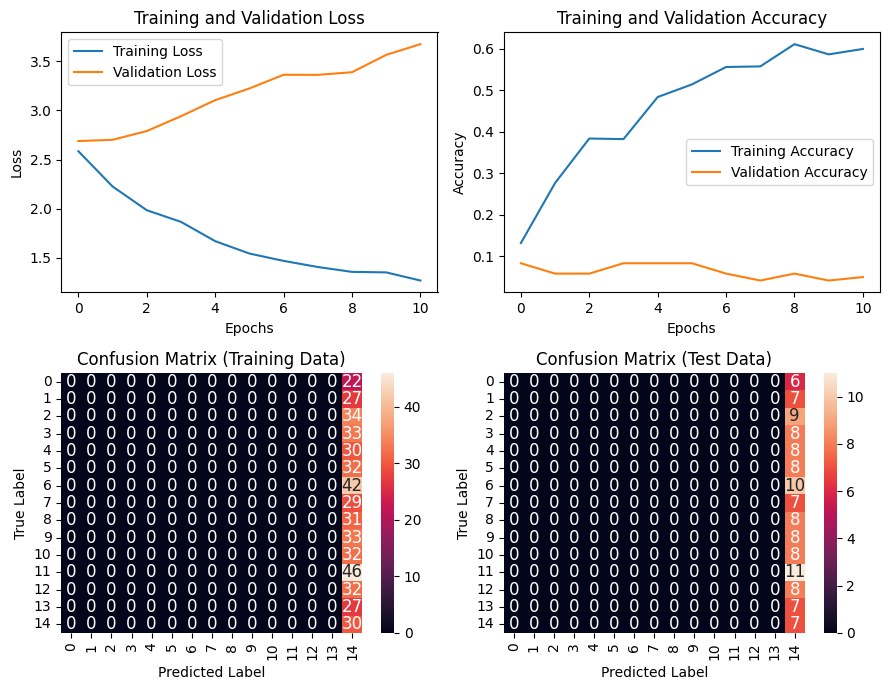

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.00      0.00      0.00         7
           2       0.00      0.00      0.00         9
           3       0.00      0.00      0.00         8
           4       0.00      0.00      0.00         8
           5       0.00      0.00      0.00         8
           6       0.00      0.00      0.00        10
           7       0.00      0.00      0.00         7
           8       0.00      0.00      0.00         8
           9       0.00      0.00      0.00         8
          10       0.00      0.00      0.00         8
          11       0.00      0.00      0.00        11
          12       0.00      0.00      0.00         8
          13       0.00      0.00      0.00         7
          14       0.06      1.00      0.11         7

    accuracy                           0.06       120
   macro avg       0.00      0.07      0.01  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [22]:
from sklearn.metrics import classification_report, confusion_matrix

# Predictions
y_train_pred = model.predict(X_train).argmax(axis=1)
y_test_pred  = model.predict(X_test).argmax(axis=1)

# Confusion matrices
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test  = confusion_matrix(y_test, y_test_pred)

# 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(9, 7))

# Top-left: Training and Validation Loss
axes[0, 0].plot(history.history['loss'], label='Training Loss')
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

# Top-right: Training and Validation Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Training Accuracy')
axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()

# Bottom-left: Confusion Matrix (Training)
sns.heatmap(cm_train, annot=True, fmt='d', ax=axes[1, 0], vmin=0, annot_kws={"size": 12})
axes[1, 0].set_title('Confusion Matrix (Training Data)')
axes[1, 0].set_xlabel('Predicted Label')
axes[1, 0].set_ylabel('True Label')

# Bottom-right: Confusion Matrix (Test)
sns.heatmap(cm_test, annot=True, fmt='d', ax=axes[1, 1], vmin=0, annot_kws={"size": 12})
axes[1, 1].set_title('Confusion Matrix (Test Data)')
axes[1, 1].set_xlabel('Predicted Label')
axes[1, 1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# Print classification report for test data
print("Classification Report (Test Data):")
print(classification_report(y_test, y_test_pred))

# Transfer Learned Model

In [23]:
from tensorflow.keras.applications import EfficientNetV2M
from tensorflow.keras.applications import MobileNetV2

# Load EfficientNetB3 without top layer
base_model = EfficientNetV2M(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
#base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False

# Display model summary
#base_model.summary()

214201816/214201816 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [24]:
# Extract features using the untrainable EfficientNetB3
X_train_encoded = base_model.predict(X_train, verbose=1)
X_test_encoded = base_model.predict(X_test, verbose=1)

print("X_train_encoded.shape:", X_train_encoded.shape)
print("X_test_encoded.shape: ", X_test_encoded.shape)

15/15 ━━━━━━━━━━━━━━━━━━━━ 37s 63ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 26s 9s/step
X_train_encoded.shape: (480, 4, 4, 1280)
X_test_encoded.shape:  (120, 4, 4, 1280)


In [25]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *

n_classes  = np.unique(y_train).shape[0]

# Create a classification head
input_encoded = Input(shape=X_train_encoded.shape[1:])
x = Flatten()(input_encoded)
x = Dropout(0.5)(x)
outputs = Dense(n_classes, activation='softmax')(x)

# Build the model
model = Model(inputs=input_encoded, outputs=outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 4, 4, 1280)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20480)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20480)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │       307,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 307,215 (1.17 MB)

 Trainable params: 307,215 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay

# define training parameters
epochs     = 50
batch_size = 256

optimizer = Adam(
    learning_rate=0.001,
)

# Compile model
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=20,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

In [27]:
history = model.fit(
    X_train_encoded, y_train,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_data=(X_test_encoded, y_test),
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.2625 - loss: 2.4756 - val_accuracy: 0.6083 - val_loss: 1.1566
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.7437 - loss: 0.8341 - val_accuracy: 0.8000 - val_loss: 0.6512
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.9021 - loss: 0.3380 - val_accuracy: 0.8417 - val_loss: 0.5201
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9542 - loss: 0.1713 - val_accuracy: 0.8583 - val_loss: 0.4044
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.9771 - loss: 0.0957 - val_accuracy: 0.8583 - val_loss: 0.3445
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.9792 - loss: 0.0688 - val_accuracy: 0.8667 - val_loss: 0.3379
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.9896 - loss: 0.0489 - val_accuracy: 0.8667 - val_loss: 0.3212
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9979 - loss: 0.0259 - val_accuracy: 0.8917 - val_loss: 0.3

In [28]:
# === FIX: Proper evaluation for encoded features (no augmentation mismatch) ===
_ = evaluate_direct(model, X_test_encoded, y_test, class_names=class_names, verbose=0, title="Fixed Evaluation: Feature Model #1")
eval

Fixed Evaluation: Feature Model #1
              precision    recall  f1-score   support

        Bean     1.0000    0.8333    0.9091         6
Bitter_Gourd     1.0000    0.8571    0.9231         7
Bottle_Gourd     1.0000    0.8889    0.9412         9
     Brinjal     0.8889    1.0000    0.9412         8
    Broccoli     1.0000    0.8750    0.9333         8
     Cabbage     1.0000    1.0000    1.0000         8
    Capsicum     1.0000    0.9000    0.9474        10
      Carrot     0.8750    1.0000    0.9333         7
 Cauliflower     1.0000    1.0000    1.0000         8
    Cucumber     0.8000    1.0000    0.8889         8
      Papaya     0.8750    0.8750    0.8750         8
      Potato     1.0000    0.9091    0.9524        11
     Pumpkin     1.0000    0.8750    0.9333         8
      Radish     0.7778    1.0000    0.8750         7
      Tomato     0.8750    1.0000    0.9333         7

    accuracy                         0.9333       120
   macro avg     0.9394    0.9342    0.9324  

<function eval(source, globals=None, locals=None, /)>

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


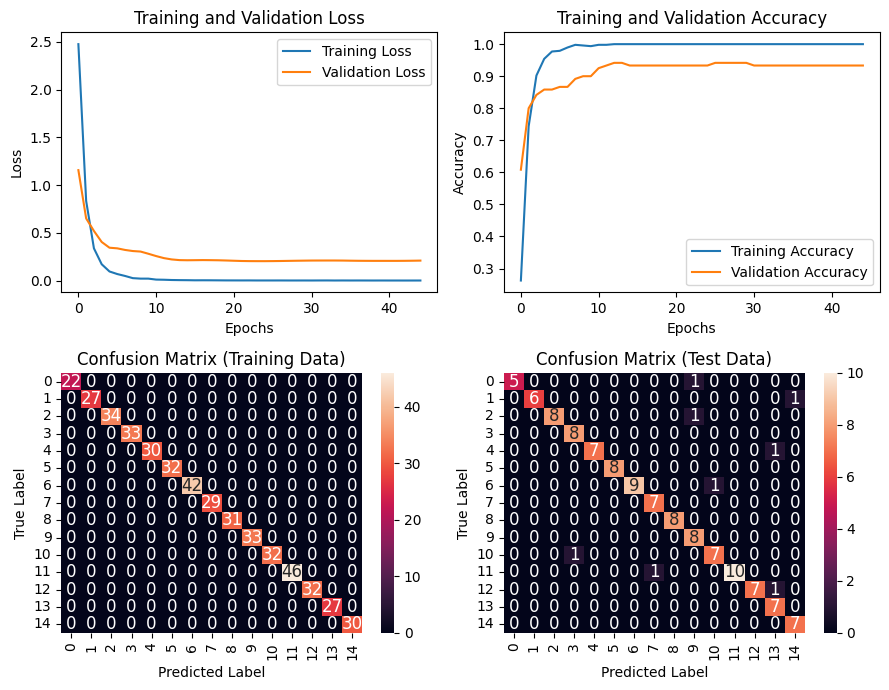

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       1.00      0.86      0.92         7
           2       1.00      0.89      0.94         9
           3       0.89      1.00      0.94         8
           4       1.00      0.88      0.93         8
           5       1.00      1.00      1.00         8
           6       1.00      0.90      0.95        10
           7       0.88      1.00      0.93         7
           8       1.00      1.00      1.00         8
           9       0.80      1.00      0.89         8
          10       0.88      0.88      0.88         8
          11       1.00      0.91      0.95        11
          12       1.00      0.88      0.93         8
          13       0.78      1.00      0.88         7
          14       0.88      1.00      0.93         7

    accuracy                           0.93       120
   macro avg       0.94      0.93      0.93  

In [29]:
from sklearn.metrics import classification_report, confusion_matrix

# Predictions
y_train_pred = model.predict(X_train_encoded).argmax(axis=1)
y_test_pred  = model.predict(X_test_encoded).argmax(axis=1)

# Confusion matrices
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test  = confusion_matrix(y_test, y_test_pred)

# 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(9, 7))

# Top-left: Training and Validation Loss
axes[0, 0].plot(history.history['loss'], label='Training Loss')
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

# Top-right: Training and Validation Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Training Accuracy')
axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()

# Bottom-left: Confusion Matrix (Training)
sns.heatmap(cm_train, annot=True, fmt='d', ax=axes[1, 0], vmin=0, annot_kws={"size": 12})
axes[1, 0].set_title('Confusion Matrix (Training Data)')
axes[1, 0].set_xlabel('Predicted Label')
axes[1, 0].set_ylabel('True Label')

# Bottom-right: Confusion Matrix (Test)
sns.heatmap(cm_test, annot=True, fmt='d', ax=axes[1, 1], vmin=0, annot_kws={"size": 12})
axes[1, 1].set_title('Confusion Matrix (Test Data)')
axes[1, 1].set_xlabel('Predicted Label')
axes[1, 1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# Print classification report for test data
print("Classification Report (Test Data):")
print(classification_report(y_test, y_test_pred))

#Visual Transformers

In [30]:
!pip install torch
!pip install transformers
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00


In [31]:
import torch
import evaluate
import numpy as np
from transformers import (ViTImageProcessor, ViTForImageClassification, TrainingArguments, Trainer)
from datasets import load_dataset

In [32]:
dataset_transformer = '/content/drive/MyDrive/Vegetable_Images/train'


full_dataset_ViT = load_dataset(
    "imagefolder",
    data_dir=dataset_transformer
)

Resolving data files:   0%|          | 0/15000 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

#Initialize Image Processor

In [33]:
model_checkpoint = "google/vit-base-patch16-224-in21k"
image_processor = ViTImageProcessor.from_pretrained(model_checkpoint)

#Extract label mappings
labels = full_dataset_ViT["train"].features["label"].names
label2id = {label: str(i) for i, label in enumerate(labels)}
id2label = {str(i): label for label, i in label2id.items()}

model = ViTForImageClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# Preprocess the Images

In [34]:
def transform(example_batch):
  inputs = image_processor([x.convert("RGB") for x in example_batch["image"]], return_tensors="pt")
  inputs["labels"] = example_batch["label"]
  return inputs

# Define data collator and metrics

In [35]:
def collate_fn(batch):
  return{
      "pixel_values": torch.stack([x["pixel_values"] for x in batch]),
      "labels": torch.tensor([x["labels"] for x in batch])
  }

metric = evaluate.load("accuracy")

def compute_metrics(p):
    return metric.compute(
        predictions=np.argmax(p.predictions, axis=1),
        references=p.label_ids
        )

# Training arguments

In [36]:
from transformers.trainer_utils import IntervalStrategy

training_args = TrainingArguments(
    output_dir="./vit-classifier-results",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    # evaluation_strategy=IntervalStrategy.EPOCH, # Removed due to TypeError
    # save_strategy="epoch", # Removed due to potential TypeError or inconsistency
    learning_rate=5e-5,
    num_train_epochs=3,
    logging_steps=10,
    remove_unused_columns=False,
    metric_for_best_model="accuracy",
    weight_decay=0.0001,
    # load_best_model_at_the_end=True, # Removed due to TypeError
    fp16=torch.cuda.is_available()
)

#Run the trainer

In [ ]:
splits = full_dataset_ViT["train"].train_test_split(test_size=0.2, seed=42)
train_dataset = splits["train"]
eval_dataset = splits["test"]

# Apply the transform function to the datasets
train_dataset = train_dataset.with_transform(transform)
eval_dataset = eval_dataset.with_transform(transform)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
)

trainer.train()

Step,Training Loss
10,0.174954
20,0.170013
30,0.147491
40,0.135603
50,0.127421
60,0.118893
70,0.111613
80,0.103671
90,0.098590
100,0.094389


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
df = pd.DataFrame(trainer.state.log_history)
df['epoch'].head(10)

In [ ]:
import matplotlib.pyplot as plt
train_logs = df[df['loss'].notna()]
eval_logs = df[df["epoch"].notna()]

#3. Create the plot
plt.figure(figsize=(10, 5))
plt.plot(train_logs['step'], train_logs['loss'], label='Training Loss')
plt.plot(eval_logs['step'], eval_logs['epoch'], label='Validation Loss')
plt.xlabel('Training Step')
plt.ylabel('Loss Value')
plt.title('ViT Training and Validation Loss Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
'''final_eval_results = trainer.evaluate()
#print(final_eval_results)

for key, value in final_eval_results.items():
    print(f"{key}: {value}")'''

# Save interupted ViT model

In [1]:
trainer.save_model("./my_interrupted_vit_model")

NameError: name 'trainer' is not defined

#Force-Save a Checkpoint

In [39]:
# Create a manual checkpoint folder
trainer.save_model("./vit-classifier-results/checkpoint-custom")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

#Look at Raw Numbers

In [40]:
import pandas as pd
#convert internal trainer logs into clean table

df = pd.DataFrame(trainer.state.log_history)
print(df.head(10))

       loss  grad_norm  learning_rate     epoch  step
0  2.594763   1.835117       0.000050  0.013333    10
1  2.332025   1.908509       0.000050  0.026667    20
2  2.019104   1.986960       0.000049  0.040000    30
3  1.795386   2.086446       0.000049  0.053333    40
4  1.554254   2.036452       0.000049  0.066667    50
5  1.352856   1.709429       0.000049  0.080000    60
6  1.164694   2.288872       0.000048  0.093333    70
7  0.988593   1.716356       0.000048  0.106667    80
8  0.874619   1.268746       0.000048  0.120000    90
9  0.792258   1.425565       0.000048  0.133333   100


# Plot training loss curve

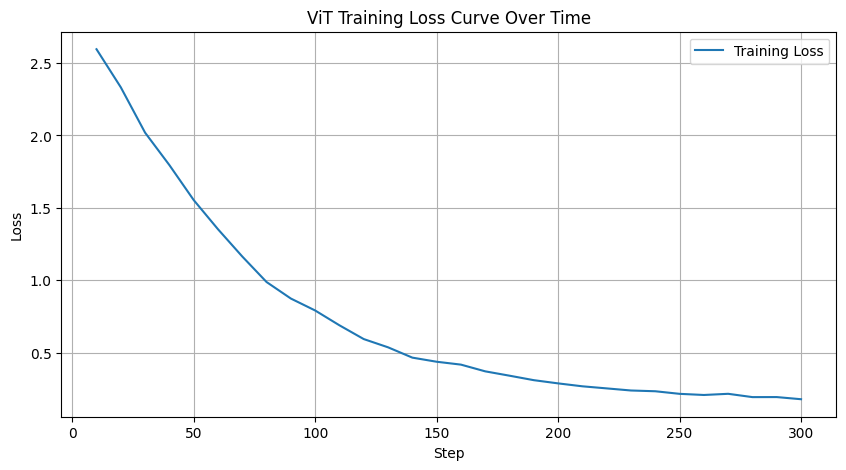

In [41]:
train_logs = [log for log in trainer.state.log_history if "loss" in log]

steps = [log["step"] for log in train_logs]
losses = [log["loss"] for log in train_logs]

plt.figure(figsize=(10, 5))
plt.plot(steps, losses, label="Training Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("ViT Training Loss Curve Over Time")
plt.legend()
plt.grid(True)
plt.show()

# Plot the Evaluation accuracy

In [42]:
eval_logs = [log for log in trainer.state.log_history if "eval_accuracy" in log]

if eval_logs:
    eval_steps = [log["step"] for log in eval_logs]
    accuracies = [log["eval_accuracy"] for log in eval_logs]

    plt.figure(figsize=(10, 5))
    plt.plot(eval_steps, accuracies, label="Validation Accuracy")
    plt.xlabel("Step")
    plt.ylabel("Accuracy")
    plt.title("ViT Validation Accuracy per Epoch")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No evaluation metrics found yet. Finish at least one full epoch or run trainer.evaluate()!")

No evaluation metrics found yet. Finish at least one full epoch or run trainer.evaluate()!


# Resume training after interruption

In [44]:
# Tells the traineer to pick up exactly where I left off
trainer.train(resume_from_checkpoint="./vit-classifier-results/checkpoint-custom")

FileNotFoundError: [Errno 2] No such file or directory: './vit-classifier-results/checkpoint-custom/trainer_state.json'

Note regarding data split consistency. If seed=42, dataset splits are locked in and perfectly reproducible meaning if you interrupt and resume, the data sequence remains exactly the same preventing data leakage.